In [ ]:
!pip install -q \
  diffusers \
  transformers \
  accelerate \
  safetensors \
  torch torchvision torchaudio \
  xformers \
  opencv-python-headless \
  pillow \
  numpy \
  scipy \
  matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.9/122.9 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 MB 27.7 MB/s eta 0:00:00


In [1]:
from huggingface_hub import login

login()

In [2]:
import cv2
import numpy as np
from PIL import Image
from diffusers.utils import load_image

original_image = load_image(
    "https://media.tenor.com/bi0bWtypZm8AAAAe/dance-funny-dance.png"
)
image = np.array(original_image)

low_threshold = 100
high_threshold = 200

image = cv2.Canny(image, low_threshold, high_threshold)
image = image[:, :, None]
image = np.concatenate([image, image, image], axis=2)
canny_image = Image.fromarray(image)

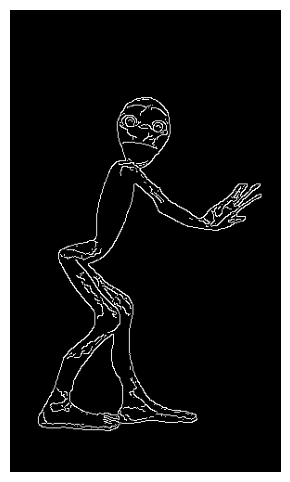

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(canny_image)
plt.axis("off")
plt.show()

In [6]:
import torch
from diffusers.utils import load_image
from diffusers import FluxControlNetPipeline, FluxControlNetModel

controlnet = FluxControlNetModel.from_pretrained(
    "InstantX/FLUX.1-dev-Controlnet-Canny", torch_dtype=torch.bfloat16
)
pipeline = FluxControlNetPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-dev", controlnet=controlnet, torch_dtype=torch.bfloat16
).to("cuda")

prompt = """
A photorealistic image of a human wearing a dance suit and dancing,
Highly realistic lighting, sharp focus, professional photography,
natural skin texture, detailed facial features.
"""

generated_image = pipeline(
    prompt,
    control_image=canny_image,
    controlnet_conditioning_scale=0.5,
    num_inference_steps=50,
    guidance_scale=3.5,
).images[0]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

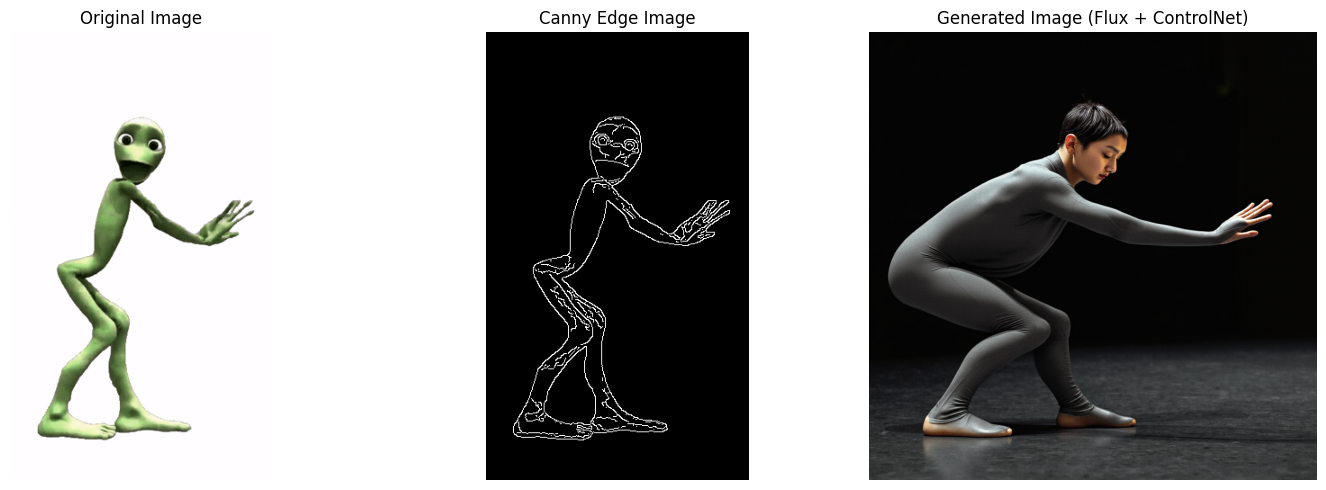

In [7]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(canny_image)
plt.title("Canny Edge Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(generated_image)
plt.title("Generated Image (Flux + ControlNet)")
plt.axis("off")

plt.tight_layout()
plt.show()

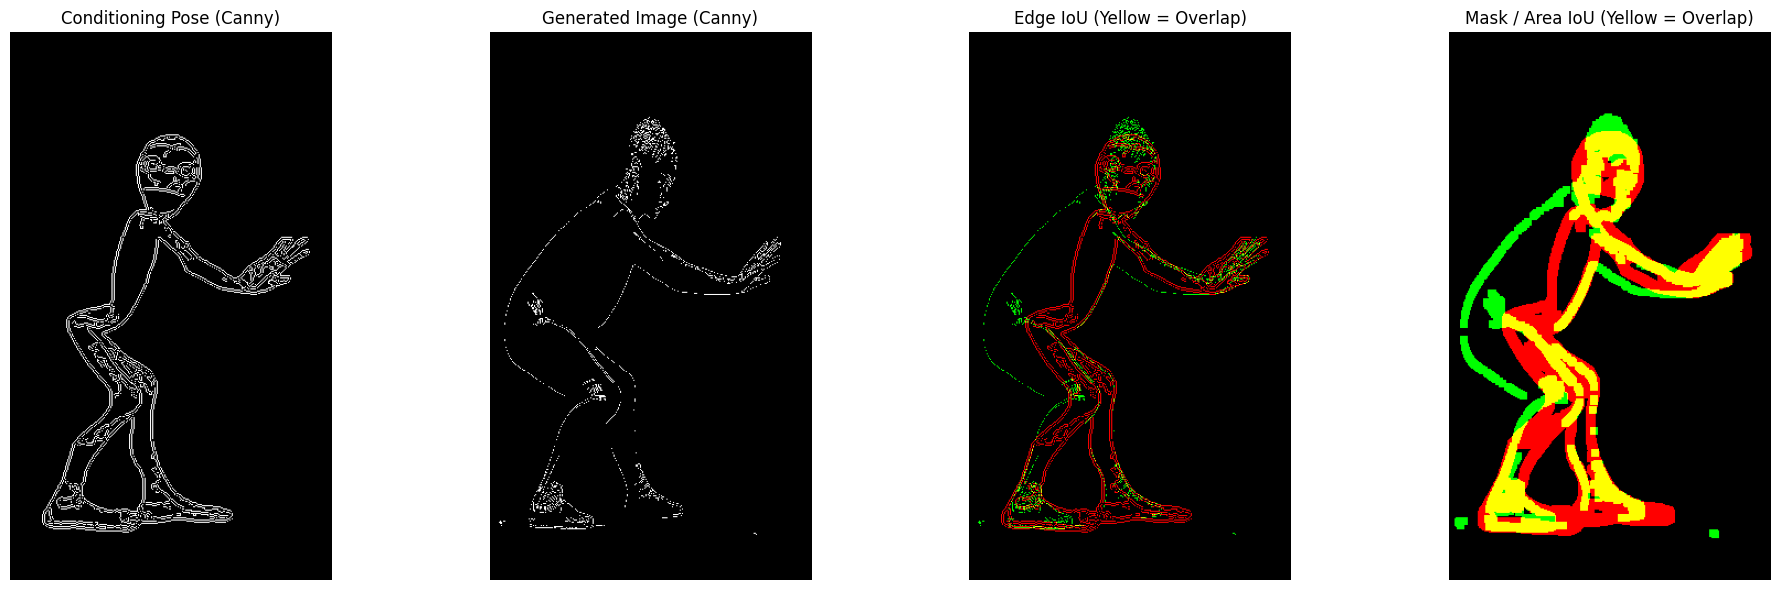

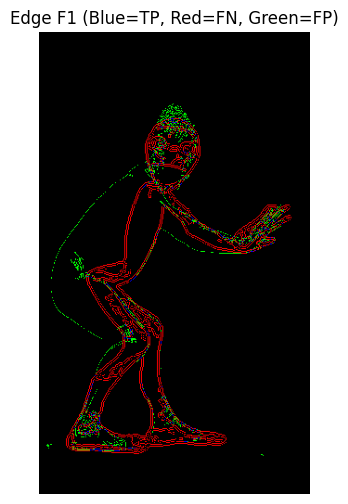

In [22]:
gen_np  = np.array(generated_image.convert("RGB"))
cond_np = np.array(canny_image.convert("RGB"))

# ----------------------------
# 2. Convert to Grayscale
# ----------------------------
gen_gray  = cv2.cvtColor(gen_np, cv2.COLOR_RGB2GRAY)
cond_gray = cv2.cvtColor(cond_np, cv2.COLOR_RGB2GRAY)

# ----------------------------
# 3. Apply Canny
# ----------------------------
low_th, high_th = 100, 200
gen_edges  = cv2.Canny(gen_gray, low_th, high_th)
cond_edges = cv2.Canny(cond_gray, low_th, high_th)

# ----------------------------
# 4. Resize generated edges
# ----------------------------
gen_edges = cv2.resize(gen_edges, (cond_edges.shape[1], cond_edges.shape[0]), interpolation=cv2.INTER_NEAREST)

# ----------------------------
# 5. Binary masks
# ----------------------------
gen_bin  = (gen_edges > 0).astype(np.uint8)
cond_bin = (cond_edges > 0).astype(np.uint8)

# ----------------------------
# 6. Edge IoU visualization (yellow = overlap)
# ----------------------------
intersection_mask = np.logical_and(gen_bin, cond_bin)
union_mask        = np.logical_or(gen_bin, cond_bin)
edge_iou_overlay = np.zeros((cond_bin.shape[0], cond_bin.shape[1], 3), dtype=np.uint8)
edge_iou_overlay[..., 0] = cond_bin*255          # Red = only conditioning
edge_iou_overlay[..., 1] = gen_bin*255           # Green = only generated
edge_iou_overlay[intersection_mask] = [255, 255, 0] # Yellow = overlap (filled)

# ----------------------------
# 7. Mask / Area IoU (dilated edges, fully filled yellow overlap)
# ----------------------------
kernel = np.ones((7,7), np.uint8)
cond_mask_area = cv2.dilate(cond_bin, kernel, iterations=1)
gen_mask_area  = cv2.dilate(gen_bin, kernel, iterations=1)
mask_iou_overlay = np.zeros((cond_bin.shape[0], cond_bin.shape[1], 3), dtype=np.uint8)
mask_iou_overlay[...,0] = cond_mask_area*255
mask_iou_overlay[...,1] = gen_mask_area*255
mask_iou_overlay[np.logical_and(cond_mask_area, gen_mask_area)] = [255, 255, 0]  # Yellow = overlap

# ----------------------------
# 8. Edge F1 visualization (Blue=TP, Red=FN, Green=FP)
# Fully filled regions
# ----------------------------
edge_f1_overlay = np.zeros((cond_bin.shape[0], cond_bin.shape[1],3), dtype=np.uint8)
TP = intersection_mask
FP = np.logical_and(gen_bin, np.logical_not(cond_bin))
FN = np.logical_and(cond_bin, np.logical_not(gen_bin))
edge_f1_overlay[TP] = [0,0,255]   # Blue = true positive (filled)
edge_f1_overlay[FP] = [0,255,0]   # Green = false positive
edge_f1_overlay[FN] = [255,0,0]   # Red = false negative

# ----------------------------
# 9. Plot all metrics
# ----------------------------
plt.figure(figsize=(20,6))

plt.subplot(1,4,1)
plt.imshow(cond_bin, cmap="gray")
plt.title("Conditioning Pose (Canny)")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gen_bin, cmap="gray")
plt.title("Generated Image (Canny)")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(edge_iou_overlay)
plt.title("Edge IoU (Yellow = Overlap)")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(mask_iou_overlay)
plt.title("Mask / Area IoU (Yellow = Overlap)")
plt.axis("off")

plt.tight_layout()-
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(edge_f1_overlay)
plt.title("Edge F1 (Blue=TP, Red=FN, Green=FP)")
plt.axis("off")
plt.show()

Edge IoU      : 0.0631
Mask / Area IoU: 0.4437
Edge F1 Score  : 0.1187


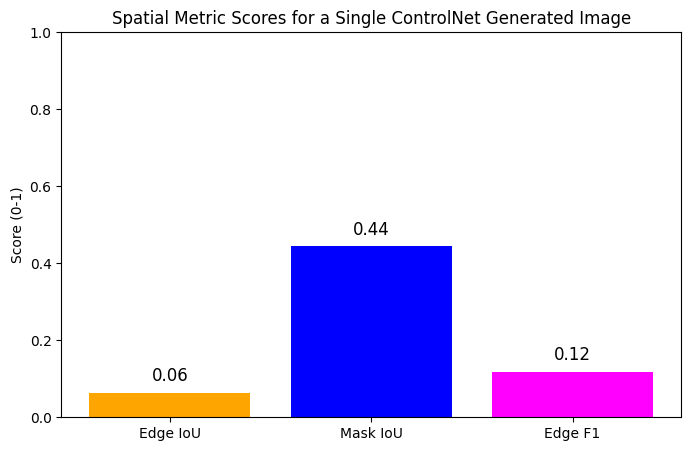

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# =========================================================
# 1. Reuse already computed masks
# gen_bin, cond_bin, intersection_mask, mask_iou_overlay
# =========================================================

# ----------------------------
# Edge IoU
# ----------------------------
edge_iou = intersection_mask.sum() / (np.logical_or(gen_bin, cond_bin).sum() + 1e-8)

# ----------------------------
# Mask / Area IoU
# Use dilated edges to simulate filled area
kernel = np.ones((7,7), np.uint8)
cond_mask_area = cv2.dilate(cond_bin, kernel, iterations=1)
gen_mask_area  = cv2.dilate(gen_bin, kernel, iterations=1)
mask_iou = np.logical_and(cond_mask_area, gen_mask_area).sum() / (np.logical_or(cond_mask_area, gen_mask_area).sum() + 1e-8)

# ----------------------------
# Edge F1 Score
# ----------------------------
edge_f1 = f1_score(cond_bin.flatten(), gen_bin.flatten(), zero_division=0)

# ----------------------------
# Print numeric results
# ----------------------------
print(f"Edge IoU      : {edge_iou:.4f}")
print(f"Mask / Area IoU: {mask_iou:.4f}")
print(f"Edge F1 Score  : {edge_f1:.4f}")

# ----------------------------
# Bar chart visualization
# ----------------------------
metrics = ['Edge IoU', 'Mask IoU', 'Edge F1']
values  = [edge_iou, mask_iou, edge_f1]

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, values, color=['orange', 'blue', 'magenta'])
plt.ylim(0, 1)
plt.ylabel("Score (0-1)")
plt.title("Spatial Metric Scores for a Single ControlNet Generated Image")

# Add text labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom', fontsize=12)

plt.show()